In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import pandas as pd
import numpy as np

# Style global
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#F8F9FC',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#E0E4EC', 'grid.linewidth': 0.7,
    'font.family': 'DejaVu Sans', 'axes.titlesize': 14,
    'axes.titleweight': 'bold', 'axes.labelsize': 12,
})
print("Imports OK")

Imports OK


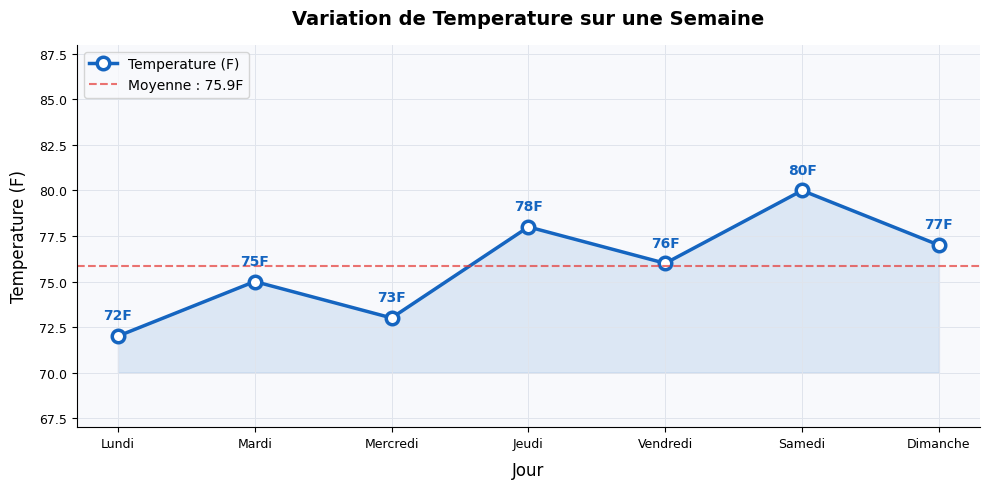

Min : 72F (Lundi)
Max : 80F (Samedi)
Moyenne : 75.9F


In [5]:
# Define sample data for temperature visualization
jours = ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi', 'Dimanche']
temperatures = [72, 75, 73, 78, 76, 80, 77]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(jours, temperatures,
        color='#1565C0', linewidth=2.5,
        marker='o', markersize=9,
        markerfacecolor='white', markeredgecolor='#1565C0', markeredgewidth=2.5,
        label='Temperature (F)')

ax.fill_between(range(len(jours)), temperatures, min(temperatures) - 2,
                alpha=0.12, color='#1565C0')

for i, (jour, temp) in enumerate(zip(jours, temperatures)):
    ax.annotate(f'{temp}F', xy=(i, temp),
                xytext=(0, 12), textcoords='offset points',
                ha='center', fontsize=10, fontweight='bold', color='#1565C0')

moy = np.mean(temperatures)
ax.axhline(moy, color='#E53935', linewidth=1.5, linestyle='--', alpha=0.7,
           label=f'Moyenne : {moy:.1f}F')

ax.set_xlabel('Jour', labelpad=8)
ax.set_ylabel('Temperature (F)', labelpad=8)
ax.set_title('Variation de Temperature sur une Semaine', pad=15)
ax.set_ylim(min(temperatures) - 5, max(temperatures) + 8)
ax.legend(fontsize=10, loc='upper left')
ax.set_xticks(range(len(jours)))
ax.set_xticklabels(jours)

plt.tight_layout()
plt.savefig('ex2_temperature.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Min : {min(temperatures)}F ({jours[temperatures.index(min(temperatures))]})")
print(f"Max : {max(temperatures)}F ({jours[temperatures.index(max(temperatures))]})")
print(f"Moyenne : {moy:.1f}F")


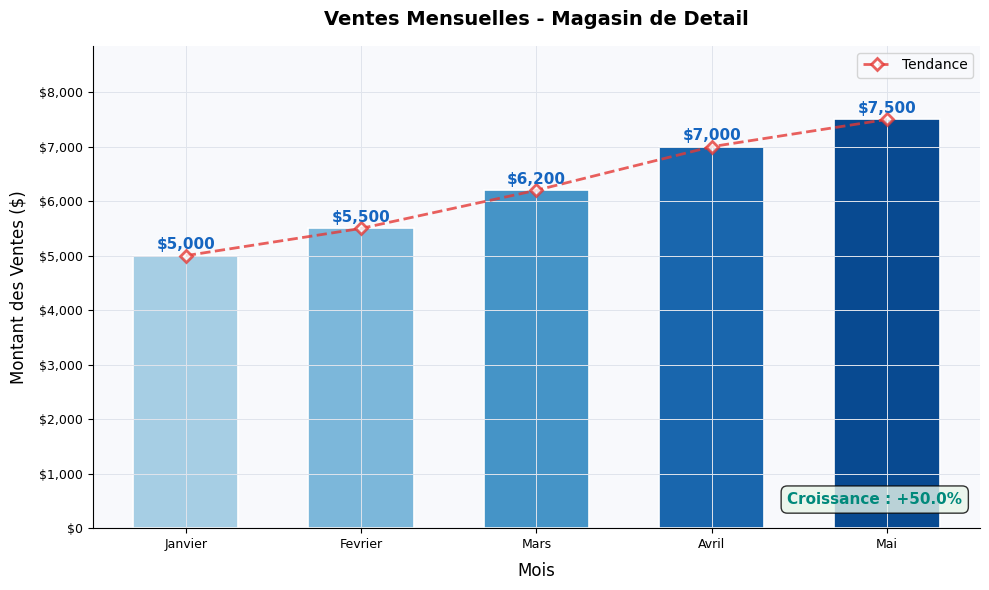

Total : $31,200  |  Croissance : +50.0%


In [6]:
mois   = ['Janvier', 'Fevrier', 'Mars', 'Avril', 'Mai']
ventes = [5000, 5500, 6200, 7000, 7500]

fig, ax = plt.subplots(figsize=(10, 6))

norm_vals = [(v - min(ventes)) / (max(ventes) - min(ventes)) for v in ventes]
colors    = [plt.cm.Blues(0.35 + 0.55 * n) for n in norm_vals]

bars = ax.bar(mois, ventes, color=colors, edgecolor='white', linewidth=1.2, width=0.6)

for bar, val in zip(bars, ventes):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 60,
            f'${val:,}',
            ha='center', va='bottom',
            fontsize=11, fontweight='bold', color='#1565C0')

ax.plot(mois, ventes, color='#E53935', linewidth=2,
        marker='D', markersize=6,
        markerfacecolor='white', markeredgecolor='#E53935', markeredgewidth=2,
        linestyle='--', alpha=0.8, label='Tendance')

ax.set_xlabel('Mois', labelpad=8)
ax.set_ylabel('Montant des Ventes ($)', labelpad=8)
ax.set_title('Ventes Mensuelles - Magasin de Detail', pad=15)
ax.set_ylim(0, max(ventes) * 1.18)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(fontsize=10)

croissance = (ventes[-1] - ventes[0]) / ventes[0] * 100
ax.text(0.98, 0.05, f'Croissance : +{croissance:.1f}%',
        transform=ax.transAxes, ha='right', fontsize=11,
        color='#00897B', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#E8F5E9', alpha=0.8))

plt.tight_layout()
plt.savefig('ex3_ventes.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Total : ${sum(ventes):,}  |  Croissance : +{croissance:.1f}%")


In [7]:
# ── Chargement ──────────────────────────────────────────────────────
health_data = pd.read_csv(r'C:\Users\meles\Documents\TTA_DI_BootCamp_Gilles-Chris_MAKE\Week2\Day4\ExerciceXP\Student Mental health.csv')
print(f"Dataset: {health_data.shape[0]} etudiants, {health_data.shape[1]} colonnes")
health_data.head(3)

Dataset: 101 etudiants, 11 colonnes


,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No


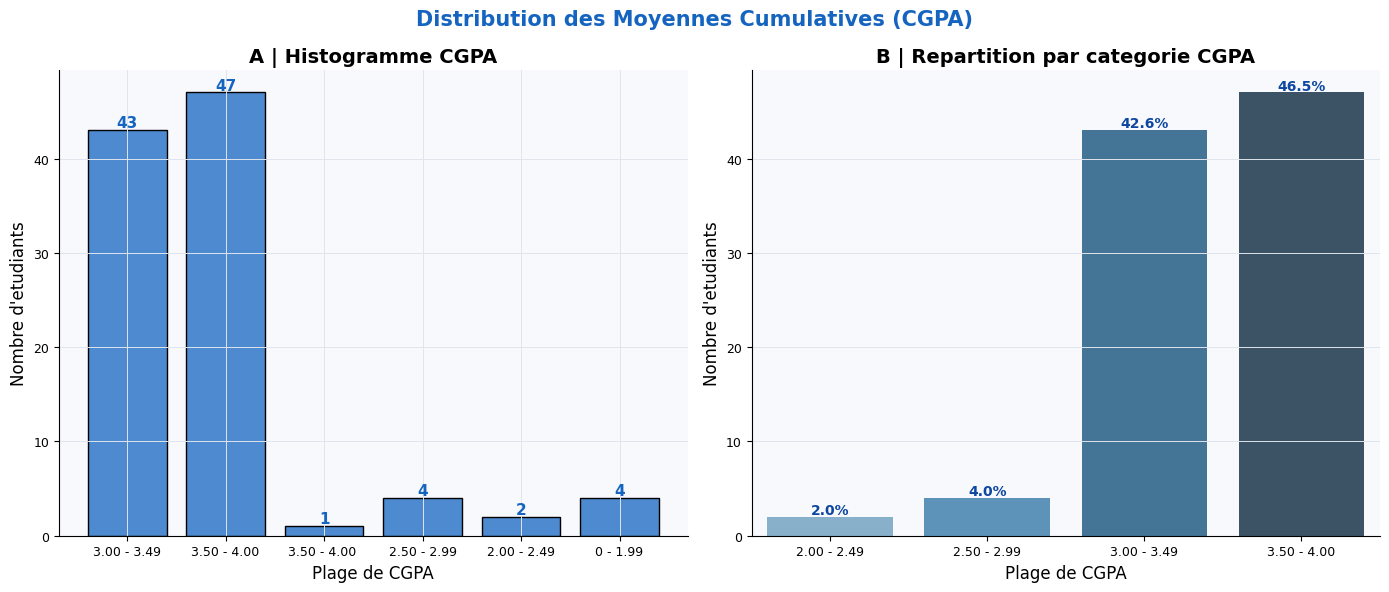

  2.00 - 2.49 : 2 etudiants (2.0%)
  2.50 - 2.99 : 4 etudiants (4.0%)
  3.00 - 3.49 : 43 etudiants (42.6%)
  3.50 - 4.00 : 47 etudiants (46.5%)


In [9]:
cgpa_order = ['2.00 - 2.49', '2.50 - 2.99', '3.00 - 3.49', '3.50 - 4.00']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Distribution des Moyennes Cumulatives (CGPA)',
             fontsize=15, fontweight='bold', color='#1565C0')

# A : histplot (distribution)
ax1 = axes[0]
sns.histplot(data=health_data, x='What is your CGPA?',
             color='#1565C0', ax=ax1, shrink=0.8)
ax1.set_title('A | Histogramme CGPA')
ax1.set_xlabel('Plage de CGPA')
ax1.set_ylabel("Nombre d'etudiants")
for patch in ax1.patches:
    h = patch.get_height()
    if h > 0:
        ax1.text(patch.get_x() + patch.get_width()/2, h + 0.3,
                 f'{int(h)}', ha='center', fontsize=11,
                 fontweight='bold', color='#1565C0')

# B : countplot ordonne
ax2 = axes[1]
sns.countplot(data=health_data, x='What is your CGPA?',
              order=cgpa_order, palette='Blues_d', ax=ax2)
ax2.set_title('B | Repartition par categorie CGPA')
ax2.set_xlabel('Plage de CGPA')
ax2.set_ylabel("Nombre d'etudiants")
total = len(health_data)
for patch in ax2.patches:
    h = patch.get_height()
    pct = h / total * 100
    ax2.text(patch.get_x() + patch.get_width()/2, h + 0.3,
             f'{pct:.1f}%', ha='center', fontsize=10,
             fontweight='bold', color='#0D47A1')

plt.tight_layout()
plt.savefig('ex4_cgpa.png', dpi=150, bbox_inches='tight')
plt.show()

counts = health_data['What is your CGPA?'].value_counts().reindex(cgpa_order)
for plage, nb in counts.items():
    print(f"  {plage} : {nb} etudiants ({nb/total*100:.1f}%)")

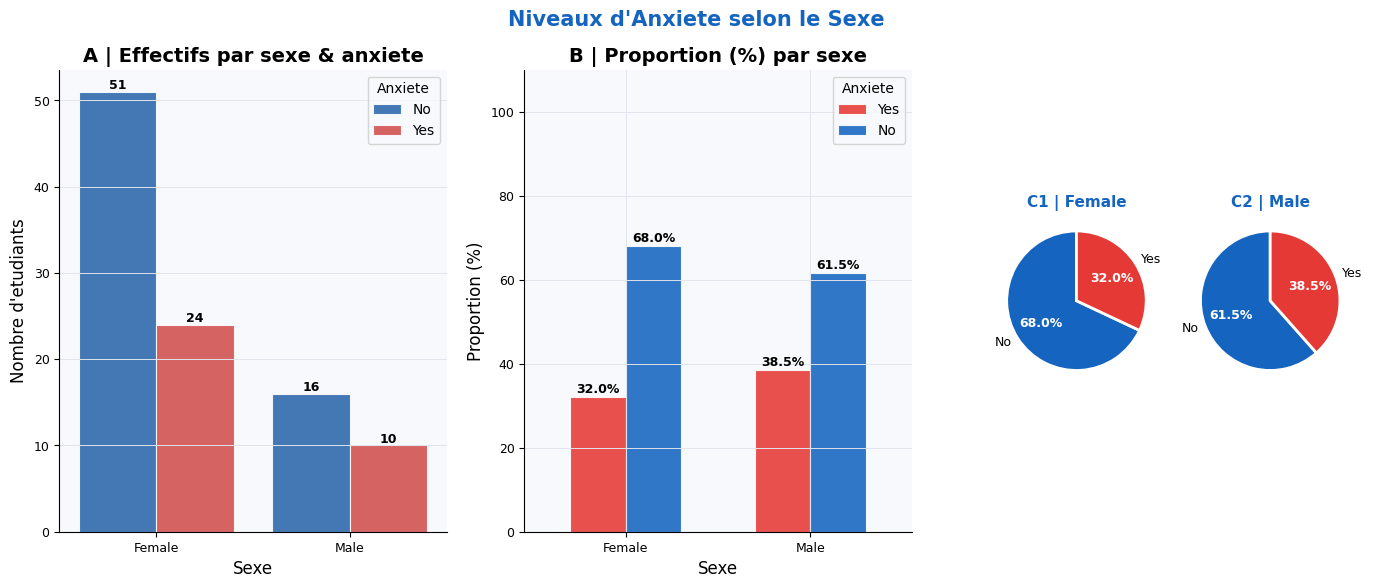

Taux d'anxiete par sexe :
Do you have Anxiety?    No   Yes
Choose your gender              
Female                68.0  32.0
Male                  61.5  38.5


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle("Niveaux d'Anxiete selon le Sexe",
             fontsize=15, fontweight='bold', color='#1565C0')

# A : Countplot groupe
ax1 = axes[0]
sns.countplot(data=health_data, x='Choose your gender',
              hue='Do you have Anxiety?',
              palette={'Yes': '#E53935', 'No': '#1565C0'},
              ax=ax1, alpha=0.88, edgecolor='white', linewidth=0.8)
ax1.set_title('A | Effectifs par sexe & anxiete')
ax1.set_xlabel('Sexe')
ax1.set_ylabel("Nombre d'etudiants")
ax1.legend(title='Anxiete')
for patch in ax1.patches:
    h = patch.get_height()
    if h > 0:
        ax1.text(patch.get_x() + patch.get_width()/2, h + 0.3,
                 f'{int(h)}', ha='center', fontsize=9, fontweight='bold')

# B : Proportion normalisee
ax2 = axes[1]
prop = (health_data.groupby(['Choose your gender', 'Do you have Anxiety?'])
          .size().unstack(fill_value=0)
          .apply(lambda x: x / x.sum() * 100, axis=1))
prop[['Yes', 'No']].plot(kind='bar', ax=ax2,
                          color=['#E53935', '#1565C0'],
                          alpha=0.88, edgecolor='white', linewidth=0.8,
                          rot=0, width=0.6)
ax2.set_title('B | Proportion (%) par sexe')
ax2.set_xlabel('Sexe')
ax2.set_ylabel('Proportion (%)')
ax2.set_ylim(0, 110)
ax2.legend(title='Anxiete')
for patch in ax2.patches:
    h = patch.get_height()
    if h > 0:
        ax2.text(patch.get_x() + patch.get_width()/2, h + 1,
                 f'{h:.1f}%', ha='center', fontsize=9, fontweight='bold')

# C : Pie par genre
ax3 = axes[2]
ax3.axis('off')
ax3_pos = ax3.get_position()
for gi, genre in enumerate(['Female', 'Male']):
    sub_data = health_data[health_data['Choose your gender'] == genre]['Do you have Anxiety?'].value_counts()
    pie_ax = fig.add_axes([ax3_pos.x0 + gi * ax3_pos.width/2,
                           ax3_pos.y0, ax3_pos.width/2 * 0.9, ax3_pos.height])
    clr = ['#E53935','#1565C0'] if sub_data.index[0]=='Yes' else ['#1565C0','#E53935']
    wedges, texts, autos = pie_ax.pie(
        sub_data.values, labels=sub_data.index, autopct='%1.1f%%',
        colors=clr, startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=2),
        textprops={'fontsize': 9})
    for a in autos:
        a.set_fontweight('bold'); a.set_color('white')
    pie_ax.set_title(f'C{gi+1} | {genre}', fontsize=11, fontweight='bold',
                     color='#1565C0', pad=5)

plt.savefig('ex5_anxiety.png', dpi=150, bbox_inches='tight')
plt.show()

print("Taux d'anxiete par sexe :")
print(prop.round(1))


In [13]:
# Conversion Yes/No -> numerique
health_data['Panic_Numeric']   = health_data['Do you have Panic attack?'].map({'Yes': 1, 'No': 0})
health_data['Anxiety_Numeric'] = health_data['Do you have Anxiety?'].map({'Yes': 1, 'No': 0})
print("Conversion effectuee :")
print(health_data['Panic_Numeric'].value_counts())

Conversion effectuee :
Panic_Numeric
0    68
1    33
Name: count, dtype: int64


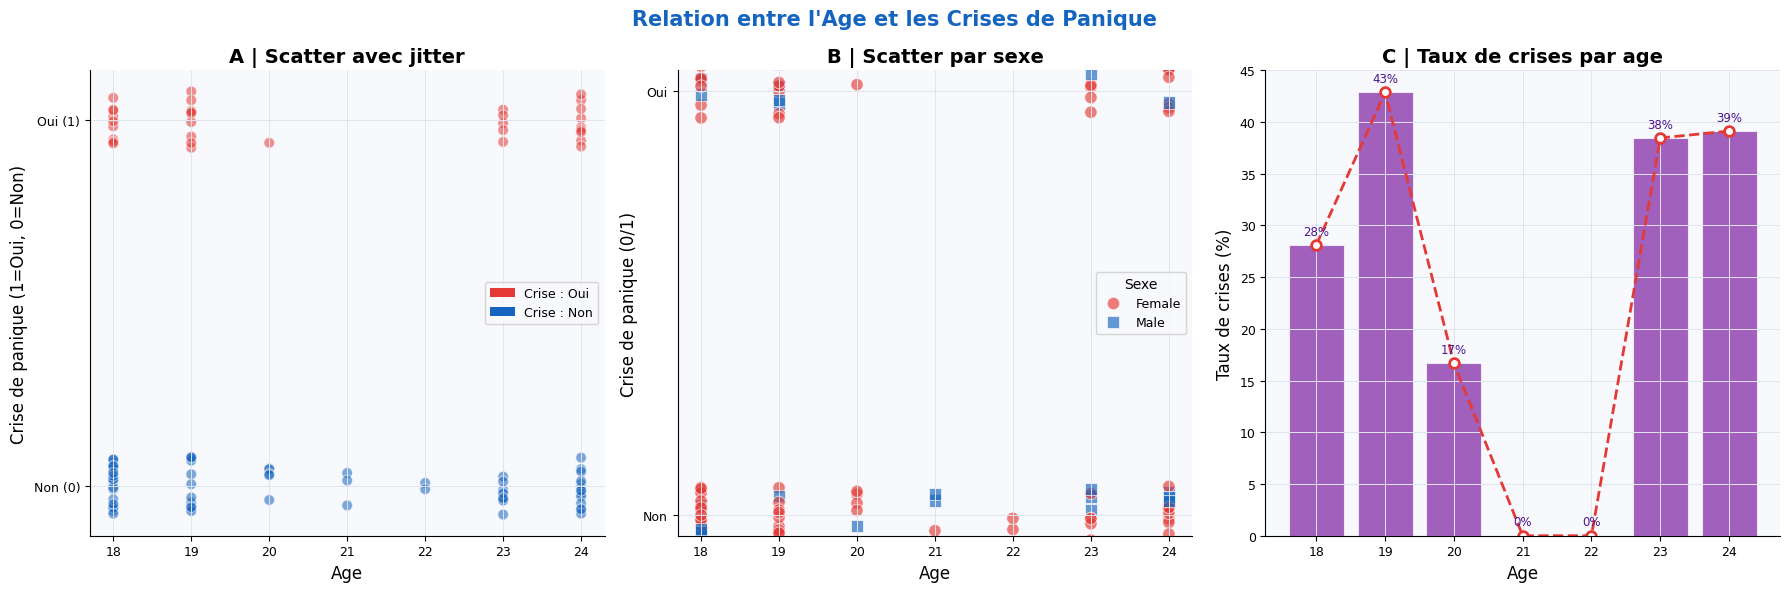

Taux global de crises : 32.7%
 Age  Count  Rate_pct
18.0     32 28.125000
19.0     21 42.857143
20.0      6 16.666667
21.0      3  0.000000
22.0      2  0.000000
23.0     13 38.461538
24.0     23 39.130435


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Relation entre l'Age et les Crises de Panique",
             fontsize=15, fontweight='bold', color='#1565C0')

np.random.seed(0)
jitter_y = np.random.uniform(-0.08, 0.08, len(health_data))

# A : Scatter avec jitter
ax1 = axes[0]
colors_scatter = ['#E53935' if p == 1 else '#1565C0' for p in health_data['Panic_Numeric']]
ax1.scatter(health_data['Age'], health_data['Panic_Numeric'] + jitter_y,
            c=colors_scatter, alpha=0.55, s=60,
            edgecolors='white', linewidth=0.8)
ax1.set_xlabel('Age')
ax1.set_ylabel('Crise de panique (1=Oui, 0=Non)')
ax1.set_yticks([0, 1])
ax1.set_yticklabels(['Non (0)', 'Oui (1)'])
ax1.set_title('A | Scatter avec jitter')
from matplotlib.patches import Patch
legend = [Patch(facecolor='#E53935', label='Crise : Oui'),
          Patch(facecolor='#1565C0', label='Crise : Non')]
ax1.legend(handles=legend, fontsize=9)

# B : Scatter par genre
ax2 = axes[1]
palette_g = {'Female': '#E53935', 'Male': '#1565C0'}
sns.scatterplot(data=health_data, x='Age', y='Panic_Numeric',
                hue='Choose your gender', palette=palette_g,
                alpha=0.65, s=80,
                style='Choose your gender',
                markers={'Female': 'o', 'Male': 's'},
                ax=ax2)
for coll in ax2.collections:
    offsets = coll.get_offsets()
    offsets[:, 1] += np.random.uniform(-0.07, 0.07, len(offsets))
    coll.set_offsets(offsets)
ax2.set_xlabel('Age')
ax2.set_ylabel('Crise de panique (0/1)')
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['Non', 'Oui'])
ax2.set_title('B | Scatter par sexe')
ax2.legend(title='Sexe', fontsize=9)

# C : Taux de crises par age
ax3 = axes[2]
panic_by_age = health_data.groupby('Age').agg(
    Rate=('Panic_Numeric', 'mean'),
    Count=('Panic_Numeric', 'count')
).reset_index()
panic_by_age['Rate_pct'] = panic_by_age['Rate'] * 100

ax3.bar(panic_by_age['Age'], panic_by_age['Rate_pct'],
        color='#7B1FA2', alpha=0.7, edgecolor='white', linewidth=0.8)
ax3.plot(panic_by_age['Age'], panic_by_age['Rate_pct'],
         'o--', color='#E53935', linewidth=2, markersize=7,
         markerfacecolor='white', markeredgewidth=2)
ax3.set_xlabel('Age')
ax3.set_ylabel('Taux de crises (%)')
ax3.set_title('C | Taux de crises par age')
ax3.set_xticks(panic_by_age['Age'])
for _, row in panic_by_age.iterrows():
    ax3.text(row['Age'], row['Rate_pct'] + 1,
             f"{row['Rate_pct']:.0f}%", ha='center', fontsize=8.5, color='#4A148C')

plt.tight_layout()
plt.savefig('ex6_panic_age.png', dpi=150, bbox_inches='tight')
plt.show()

total_panic = health_data['Panic_Numeric'].mean() * 100
print(f"Taux global de crises : {total_panic:.1f}%")
print(panic_by_age[['Age', 'Count', 'Rate_pct']].to_string(index=False))
